# End-of-chapter project — Palmer Penguins classification

**Chapter 5 · Unit 1 — Practicing scikit-learn end-to-end**

Welcome! This is your final practice project before the chapter ends. You will build a complete classification pipeline from raw data to a tuned model, exactly the way a junior data scientist would on their first project at work.

## The dataset

The **Palmer Penguins** dataset contains body measurements of 344 penguins observed near Palmer Station in Antarctica between 2007 and 2009. The data was collected by Dr. Kristen Gorman with the Palmer Station Long Term Ecological Research Program, and was released as a modern, friendlier alternative to the Iris dataset that classification notebooks have used since the 1930s.

There are three species in our data:

- **Adelie** *(Pygoscelis adeliae)* — the smallest of the three, found on all three islands.
- **Gentoo** *(Pygoscelis papua)* — the largest, found only on Biscoe Island.
- **Chinstrap** *(Pygoscelis antarcticus)* — recognizable by the thin black band under the chin, found only on Dream Island.

For each penguin we have its species, the island it was observed on, four body measurements (bill length, bill depth, flipper length, body mass), the sex, and the year of observation.

## Your mission

Train a classifier that, given the body measurements, can predict the species of a new penguin. Along the way you will exercise every concept from this chapter:

1. Loading and inspecting real data
2. Handling missing values
3. Visualizing relationships between features and the target
4. Encoding categorical features with **one-hot encoding**
5. Splitting into train and test sets
6. Training a Decision Tree
7. Evaluating with a confusion matrix and a classification report
8. Cross-validation
9. Hyperparameter tuning with `GridSearchCV`
10. Reading feature importances

Throughout the notebook you will see colored boxes:

<div style="background-color: #fef3c7; border-left: 4px solid #f59e0b; padding: 8px 12px; margin: 4px 0;"><strong>Question for you</strong> — short conceptual questions; jot down your answer before reading on.</div>
<div style="background-color: #dbeafe; border-left: 4px solid #3b82f6; padding: 8px 12px; margin: 4px 0;"><strong>Tip</strong> — useful shortcuts and clarifications.</div>
<div style="background-color: #fee2e2; border-left: 4px solid #ef4444; padding: 8px 12px; margin: 4px 0;"><strong>Watch out</strong> — common mistakes to avoid.</div>
<div style="background-color: #dcfce7; border-left: 4px solid #16a34a; padding: 8px 12px; margin: 4px 0;"><strong>Try it yourself</strong> — extended hands-on exercises.</div>


## 0. Setup

The dataset lives in the small `palmerpenguins` package. If you don't have it, the cell below will install it.

In [1]:
# Run once if needed
%pip install palmerpenguins

Defaulting to user installation because normal site-packages is not writeableNote: you may need to restart the kernel to use updated packages.



In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import palmerpenguins

from palmerpenguins import load_penguins

from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.tree            import DecisionTreeClassifier
from sklearn.metrics         import (accuracy_score, confusion_matrix,
                                     classification_report, ConfusionMatrixDisplay)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False

# Our color palette for the three species — used consistently throughout the notebook
SPECIES_PALETTE = {"Adelie": "#D85A30", "Gentoo": "#1D9E75", "Chinstrap": "#534AB7"}

RANDOM_STATE = 42

## 1. Load and inspect the data

Always look at your data before doing anything else. The first ten minutes you spend exploring will save you hours of debugging later.

In [5]:
penguins = load_penguins()
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


In [7]:
print(f"Shape: {penguins.shape[0]} rows × {penguins.shape[1]} columns")
print()
print("Column types:")
print(penguins.dtypes)

Shape: 344 rows × 8 columns

Column types:
species               object
island                object
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                   object
year                   int64
dtype: object


<div style="background-color: #fef3c7; border-left: 4px solid #f59e0b; padding: 12px 16px; border-radius: 4px; margin: 16px 0;"><strong>Question for you</strong><br>Look at the column types above. Which columns are <strong>numerical</strong> and which are <strong>categorical</strong>? Which one is the <em>target</em> we want to predict?</div>

## 2. How balanced are the classes?

Before training any model, check whether the classes are roughly balanced. Imbalance affects which metrics you should trust and how you should split your data.

species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

Proportions:
species
Adelie       0.442
Gentoo       0.360
Chinstrap    0.198
Name: count, dtype: float64


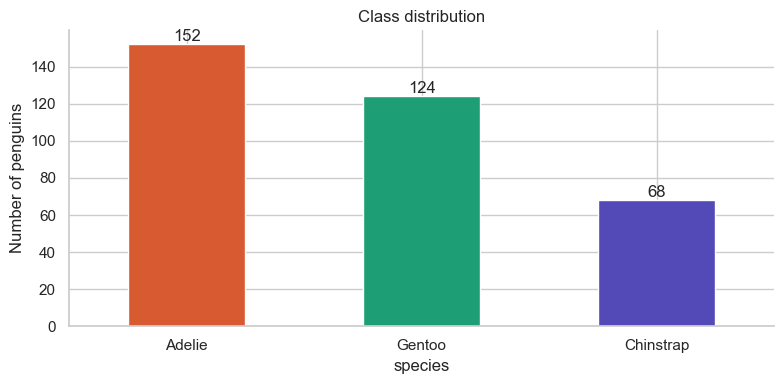

In [9]:
class_counts = penguins["species"].value_counts()
print(class_counts)
print()
print("Proportions:")
print((class_counts / class_counts.sum()).round(3))

ax = class_counts.plot(kind="bar",
                       color=[SPECIES_PALETTE[s] for s in class_counts.index],
                       rot=0)
ax.set_title("Class distribution")
ax.set_ylabel("Number of penguins")
ax.bar_label(ax.containers[0])
plt.tight_layout()
plt.show()

<div style="background-color: #fef3c7; border-left: 4px solid #f59e0b; padding: 12px 16px; border-radius: 4px; margin: 16px 0;"><strong>Question for you</strong><br>The classes are <strong>not balanced</strong>: Chinstrap has roughly half as many samples as Adelie. Predict what will happen if we don't account for this:<br>(a) Will a baseline that always predicts "Adelie" beat 50% accuracy?<br>(b) When we split into train/test sets, why might the test split end up with very few Chinstraps if we forget to use <code>stratify</code>?</div>

## 3. The categorical features — `island` and `sex`

This dataset has **categorical** input features. We'll need to convert them to numbers before any scikit-learn model can use them.

In [11]:
print("Penguins per island:")
print(penguins["island"].value_counts())
print()
print("Sex distribution:")
print(penguins["sex"].value_counts(dropna=False))

Penguins per island:
island
Biscoe       168
Dream        124
Torgersen     52
Name: count, dtype: int64

Sex distribution:
sex
male      168
female    165
NaN        11
Name: count, dtype: int64


In [13]:
# Cross-tabulate island and species — does where a penguin lives tell us much?
pd.crosstab(penguins["island"], penguins["species"])

species,Adelie,Chinstrap,Gentoo
island,,,
Biscoe,44,0,124
Dream,56,68,0
Torgersen,52,0,0


<div style="background-color: #fef3c7; border-left: 4px solid #f59e0b; padding: 12px 16px; border-radius: 4px; margin: 16px 0;"><strong>Question for you</strong><br>The crosstab above is striking. Look at it carefully:<br>(a) If you only knew that a penguin was observed on <em>Torgersen</em>, what species would you guess?<br>(b) Which island would give you the <em>least</em> information about species?<br>(c) The <code>island</code> column alone could classify many penguins correctly. Do you think this counts as "cheating", or is it legitimate signal? Discuss with a classmate.</div>

## 4. Handle missing values

Real datasets have missing values. The penguins data has a few — let's find them.

In [17]:
missing = penguins.isnull().sum()
print(missing)
print(f"\nTotal rows with at least one missing value: {penguins.isnull().any(axis=1).sum()}")

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
year                  0
dtype: int64

Total rows with at least one missing value: 11


<div style="background-color: #dbeafe; border-left: 4px solid #3b82f6; padding: 12px 16px; border-radius: 4px; margin: 16px 0;"><strong>Tip</strong><br>There are several legitimate strategies for handling missing values:<br><ul style='margin:6px 0;'><li><strong>Drop rows</strong> with any missing value. Simple, but you lose information.</li><li><strong>Impute</strong> the missing value with the column mean (numeric) or mode (categorical).</li><li><strong>Model-based imputation</strong> — predict the missing value from the others.</li><li><strong>Treat "missing" as its own category</strong> for categorical variables.</li></ul>The right choice depends on <em>why</em> values are missing and how many you have. Here we have only 11 affected rows out of 344 (about 3%), so dropping is reasonable.</div>

In [19]:
penguins_clean = penguins.dropna().reset_index(drop=True)
print(f"Before: {len(penguins)} rows")
print(f"After:  {len(penguins_clean)} rows ({len(penguins) - len(penguins_clean)} dropped)")

Before: 344 rows
After:  333 rows (11 dropped)


<div style="background-color: #fef3c7; border-left: 4px solid #f59e0b; padding: 12px 16px; border-radius: 4px; margin: 16px 0;"><strong>Question for you</strong><br>Suppose 80% of the <code>sex</code> column was missing instead of 3%. Would you still drop rows? What about imputing every missing sex with the most common value? What problem could that introduce when training a classifier?</div>

## 5. Explore the relationships visually

This is where the project becomes fun. Good visualizations tell you immediately what your model will learn — and where it will struggle.

### 5.1 — The pairplot: every feature vs every other feature

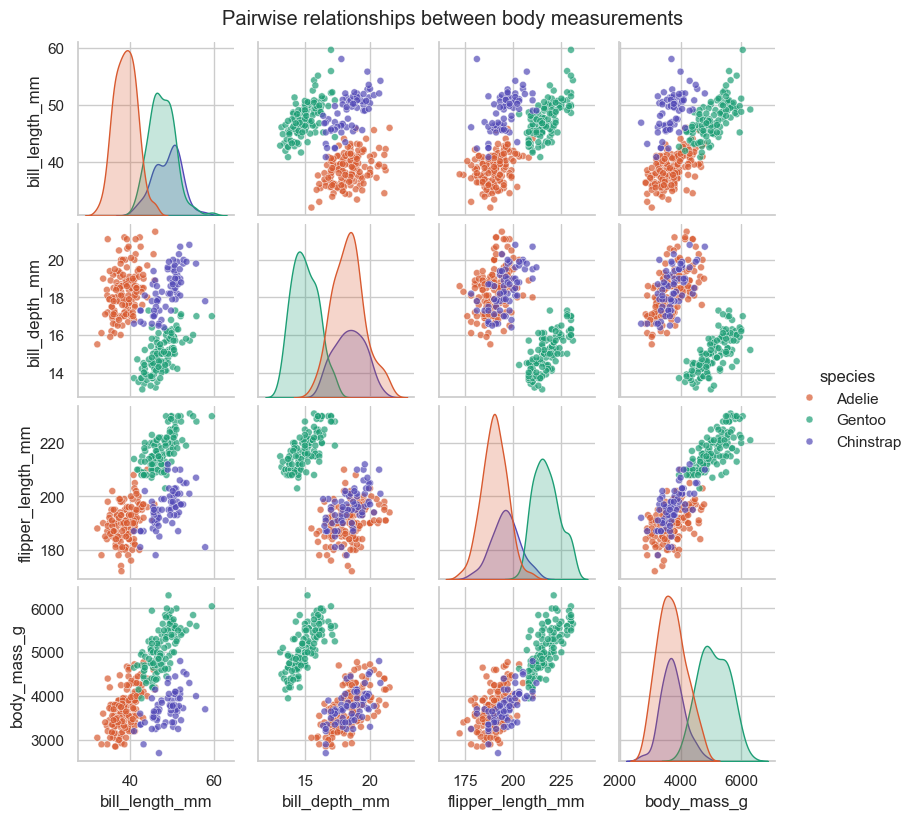

In [21]:
# Pairplot of all four numerical measurements, colored by species
sns.pairplot(
    penguins_clean,
    vars=["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"],
    hue="species",
    palette=SPECIES_PALETTE,
    height=2.0,
    plot_kws={"alpha": 0.7, "s": 25},
)
plt.suptitle("Pairwise relationships between body measurements", y=1.02)
plt.show()

<div style="background-color: #fef3c7; border-left: 4px solid #f59e0b; padding: 12px 16px; border-radius: 4px; margin: 16px 0;"><strong>Question for you</strong><br>The pairplot is doing most of the work for you. Spend a minute studying it before answering:<br>(a) Which <strong>single feature</strong> separates the three species best, on its own?<br>(b) Which <strong>pair of features</strong> separates them almost perfectly?<br>(c) Which two species are hardest to tell apart with just body measurements? Look at the subplot where they overlap most.</div>

### 5.2 — The famous bill length / bill depth view

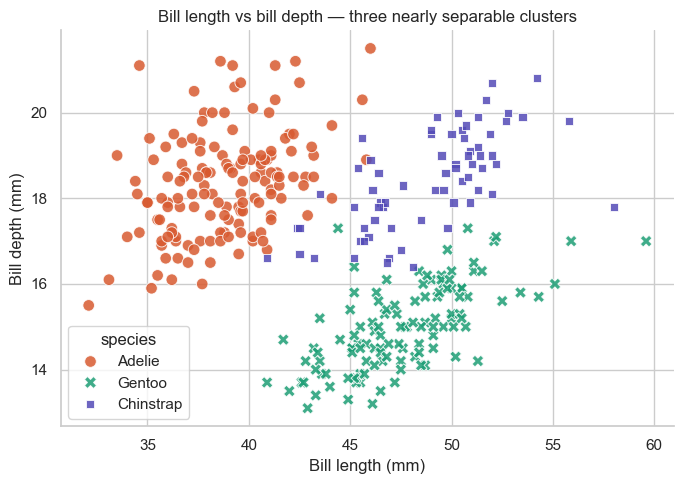

In [23]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(data=penguins_clean,
                x="bill_length_mm", y="bill_depth_mm",
                hue="species", style="species",
                palette=SPECIES_PALETTE, s=70, alpha=0.85, ax=ax)
ax.set_title("Bill length vs bill depth — three nearly separable clusters")
ax.set_xlabel("Bill length (mm)")
ax.set_ylabel("Bill depth (mm)")
plt.tight_layout()
plt.show()

<div style="background-color: #dbeafe; border-left: 4px solid #3b82f6; padding: 12px 16px; border-radius: 4px; margin: 16px 0;"><strong>Tip</strong><br>This view is the dataset's signature plot. Notice that Gentoo penguins have <strong>long, shallow bills</strong>; Chinstraps have <strong>long, deep bills</strong>; Adelies have <strong>short, deep bills</strong>. A classifier shown only these two features would already do quite well. We will see this borne out in the feature-importance results later.</div>

### 5.3 — Distribution of each feature by species

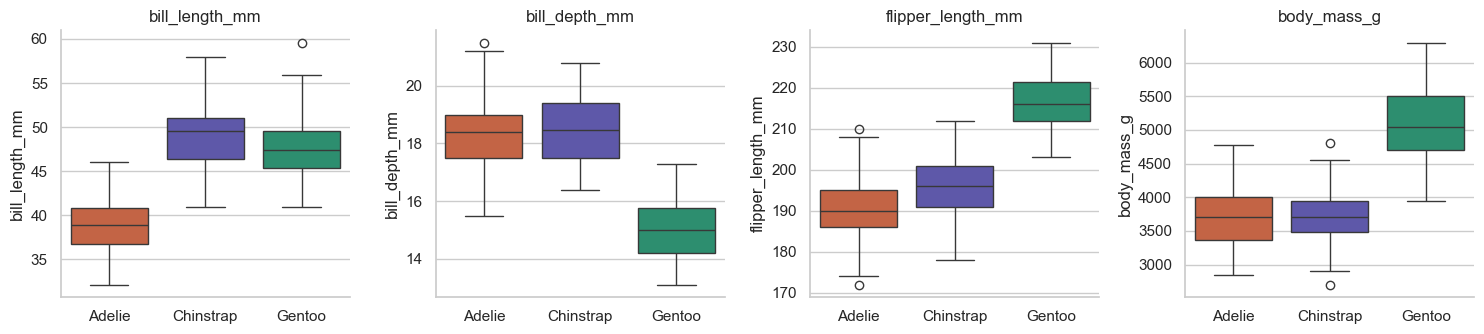

In [25]:
features = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
fig, axes = plt.subplots(1, 4, figsize=(15, 3.5))

for ax, feat in zip(axes, features):
    sns.boxplot(data=penguins_clean, x="species", y=feat,
                hue="species", legend=False,
                order=["Adelie", "Chinstrap", "Gentoo"],
                palette=SPECIES_PALETTE, ax=ax)
    ax.set_title(feat)
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

<div style="background-color: #fef3c7; border-left: 4px solid #f59e0b; padding: 12px 16px; border-radius: 4px; margin: 16px 0;"><strong>Question for you</strong><br>Look at <code>flipper_length_mm</code> and <code>body_mass_g</code>. Both clearly separate <strong>Gentoo</strong> from the other two species, but Adelie and Chinstrap overlap heavily. Now look at <code>bill_length_mm</code> — what does it tell you that the other two don't?</div>

## 6. Encode the categorical features (one-hot encoding)

scikit-learn models expect numerical input. We have two categorical columns to handle: `island` (3 values) and `sex` (2 values).

The right tool is **one-hot encoding** — for a column with K possible values we create K new binary columns, one per value, and put a 1 in the column that matches the row's value.

<div style="background-color: #fee2e2; border-left: 4px solid #ef4444; padding: 12px 16px; border-radius: 4px; margin: 16px 0;"><strong>Watch out</strong><br>A common beginner mistake is to use <code>LabelEncoder</code> here, which assigns <code>Torgersen → 0, Biscoe → 1, Dream → 2</code>. The model would then think Dream is "twice as much" as Biscoe — but these are <em>unordered</em> categories, that ordering is meaningless. Use one-hot encoding for unordered categories. Save label encoding for cases where the order actually matters (e.g. <code>'small' &lt; 'medium' &lt; 'large'</code>).</div>

In [27]:
# pd.get_dummies does one-hot encoding in one line
penguins_encoded = pd.get_dummies(
    penguins_clean,
    columns=["island", "sex"],
    drop_first=False,    # keep all columns for clarity; True is fine for tree models
)

# Look at the new columns
print("Original columns:", list(penguins_clean.columns))
print()
print("After one-hot:   ", list(penguins_encoded.columns))

Original columns: ['species', 'island', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex', 'year']

After one-hot:    ['species', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'year', 'island_Biscoe', 'island_Dream', 'island_Torgersen', 'sex_female', 'sex_male']


In [ ]:
penguins_encoded.head()

<div style="background-color: #fef3c7; border-left: 4px solid #f59e0b; padding: 12px 16px; border-radius: 4px; margin: 16px 0;"><strong>Question for you</strong><br>Why did <code>island</code> become <strong>three</strong> new columns but <code>sex</code> only <strong>two</strong>? What information is encoded in each new column?</div>

## 7. Split into features and target, then train and test

We separate the species column (our target `y`) from everything else (our features `X`), then hold out 25% as a test set. We use `stratify=y` to preserve class proportions because Chinstrap is the minority class.

In [29]:
# Drop the year too — it's not a biological feature
X = penguins_encoded.drop(columns=["species", "year"])
y = penguins_encoded["species"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    stratify=y,
    random_state=RANDOM_STATE,
)

print(f"Training set: {len(X_train)} samples, {X_train.shape[1]} features")
print(f"Test set:     {len(X_test)} samples")
print()
print("Class proportions — train:")
print((y_train.value_counts(normalize=True).round(3)).to_string())
print("\nClass proportions — test:")
print((y_test.value_counts(normalize=True).round(3)).to_string())

Training set: 249 samples, 9 features
Test set:     84 samples

Class proportions — train:
species
Adelie       0.438
Gentoo       0.357
Chinstrap    0.205

Class proportions — test:
species
Adelie       0.440
Gentoo       0.357
Chinstrap    0.202


## 8. Train a Decision Tree

We start with a Decision Tree because it's interpretable, fast, and handles mixed feature scales without complaint.

In [31]:
tree = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,           # cap depth to avoid overfitting
    random_state=RANDOM_STATE,
)
tree.fit(X_train, y_train)

y_pred = tree.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)
print(f"Test accuracy: {test_accuracy:.4f}")

Test accuracy: 0.9286


### 8.1 — Confusion matrix

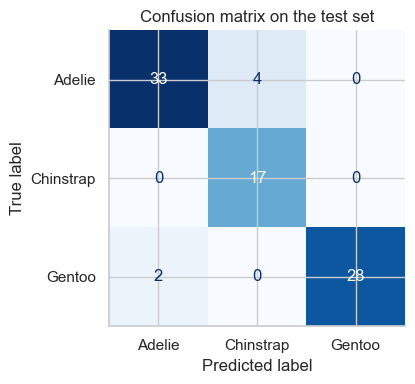

In [33]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    labels=["Adelie", "Chinstrap", "Gentoo"],
    cmap="Blues",
    colorbar=False,
    ax=ax,
)
ax.set_title("Confusion matrix on the test set")
plt.tight_layout()
plt.show()

### 8.2 — Classification report — precision, recall, F1 per class

In [35]:
print(classification_report(y_test, y_pred, digits=3))

              precision    recall  f1-score   support

      Adelie      0.943     0.892     0.917        37
   Chinstrap      0.810     1.000     0.895        17
      Gentoo      1.000     0.933     0.966        30

    accuracy                          0.929        84
   macro avg      0.917     0.942     0.926        84
weighted avg      0.936     0.929     0.930        84



<div style="background-color: #fef3c7; border-left: 4px solid #f59e0b; padding: 12px 16px; border-radius: 4px; margin: 16px 0;"><strong>Question for you</strong><br>The classification report shows three scores per class: precision, recall, F1.<br>(a) Which species, if any, has the lowest <strong>recall</strong>? What does that mean in plain English?<br>(b) Which species has the lowest <strong>precision</strong>? What does that mean in plain English?<br>(c) Why is <code>weighted avg</code> a more honest summary than <code>macro avg</code> when classes are imbalanced?</div>

## 9. Cross-validation — a more reliable estimate

A single train/test split is noisy: with a different random seed we'd get a different accuracy. **K-fold cross-validation** divides the data into K folds, trains on K-1 of them, evaluates on the held-out one, and repeats K times. The mean of the K scores is much more stable than a single split.

In [37]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(tree, X_train, y_train, cv=cv, scoring="accuracy")

print("Per-fold accuracies:")
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {score:.4f}")
print(f"\nMean: {cv_scores.mean():.4f}   Std: {cv_scores.std():.4f}")

Per-fold accuracies:
  Fold 1: 0.9400
  Fold 2: 0.9200
  Fold 3: 0.9600
  Fold 4: 1.0000
  Fold 5: 0.9592

Mean: 0.9558   Std: 0.0265


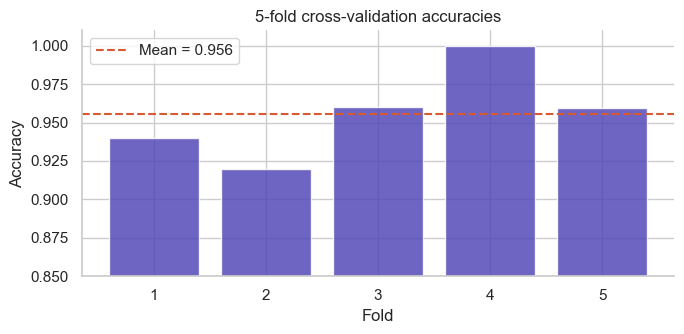

In [39]:
# Visualize the spread
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(range(1, 6), cv_scores, color="#534AB7", alpha=0.85)
ax.axhline(cv_scores.mean(), color="#D85A30", linestyle="--",
           label=f"Mean = {cv_scores.mean():.3f}")
ax.set_xticks(range(1, 6))
ax.set_xlabel("Fold")
ax.set_ylabel("Accuracy")
ax.set_ylim(0.85, 1.01)
ax.set_title("5-fold cross-validation accuracies")
ax.legend()
plt.tight_layout()
plt.show()

<div style="background-color: #fef3c7; border-left: 4px solid #f59e0b; padding: 12px 16px; border-radius: 4px; margin: 16px 0;"><strong>Question for you</strong><br>Compare the cross-validation mean to the single test-set accuracy you got in §8. Are they close?<br><br>Now look at the <strong>standard deviation</strong> across folds. If it were 10× larger, what would that tell you about how trustworthy your reported accuracy is?</div>

## 10. Hyperparameter tuning with GridSearchCV

We picked `max_depth=5` and `criterion="gini"` somewhat arbitrarily. Let's let the data tell us what's best by searching a grid of combinations and picking the one with the best cross-validated accuracy.

In [41]:
param_grid = {
    "criterion":         ["gini", "entropy"],
    "max_depth":         [3, 4, 5, 6, 8, 10, None],
    "min_samples_leaf":  [1, 2, 5, 10],
}

grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_grid=param_grid,
    cv=KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring="accuracy",
    n_jobs=-1,           # use all CPU cores
    verbose=0,
)
grid.fit(X_train, y_train)

print(f"Total combinations searched: {len(grid.cv_results_['params'])}")
print(f"Best cross-validated accuracy: {grid.best_score_:.4f}")
print(f"Best parameters: {grid.best_params_}")

Total combinations searched: 56
Best cross-validated accuracy: 0.9599
Best parameters: {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 1}


### 10.1 — How sensitive is accuracy to `max_depth`?

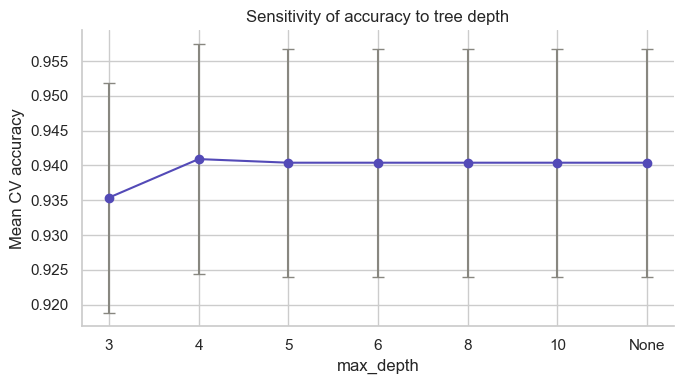

In [42]:
# Pull cv_results_ into a DataFrame for a tidy plot
results = pd.DataFrame(grid.cv_results_)

# Aggregate: mean CV accuracy per max_depth (averaged over the other hyperparameters)
depth_summary = (results
                 .groupby("param_max_depth", dropna=False)["mean_test_score"]
                 .agg(["mean", "std"])
                 .reset_index())

# x-axis labels — None becomes the literal string "None" (no tree depth limit)
depth_labels = ["None" if pd.isna(d) else str(int(d))
                for d in depth_summary["param_max_depth"]]

fig, ax = plt.subplots(figsize=(7, 4))
ax.errorbar(depth_labels, depth_summary["mean"].to_numpy(),
            yerr=depth_summary["std"].to_numpy(), marker="o", capsize=4,
            color="#534AB7", ecolor="#888780")
ax.set_xlabel("max_depth")
ax.set_ylabel("Mean CV accuracy")
ax.set_title("Sensitivity of accuracy to tree depth")
plt.tight_layout()
plt.show()

<div style="background-color: #fef3c7; border-left: 4px solid #f59e0b; padding: 12px 16px; border-radius: 4px; margin: 16px 0;"><strong>Question for you</strong><br>The accuracy curve is fairly flat past <code>max_depth=4</code>. What does this tell you about the complexity of the decision boundary in this problem?<br><br>If two configurations give essentially the same CV accuracy, which one should you prefer — the simpler tree or the deeper one? Why? (Look up <em>Occam's razor</em> if you're not sure.)</div>

### 10.2 — Final evaluation on the held-out test set

In [45]:
best_model = grid.best_estimator_
y_pred_best = best_model.predict(X_test)

print(f"Test accuracy of the tuned model: {accuracy_score(y_test, y_pred_best):.4f}")
print()
print(classification_report(y_test, y_pred_best, digits=3))

Test accuracy of the tuned model: 0.9643

              precision    recall  f1-score   support

      Adelie      0.925     1.000     0.961        37
   Chinstrap      1.000     0.941     0.970        17
      Gentoo      1.000     0.933     0.966        30

    accuracy                          0.964        84
   macro avg      0.975     0.958     0.965        84
weighted avg      0.967     0.964     0.964        84



## 11. Which features actually matter?

Decision Trees give us a `feature_importances_` attribute showing how much each feature contributes to splitting decisions across the tree. This is one of the simplest ways to get intuition about your data.

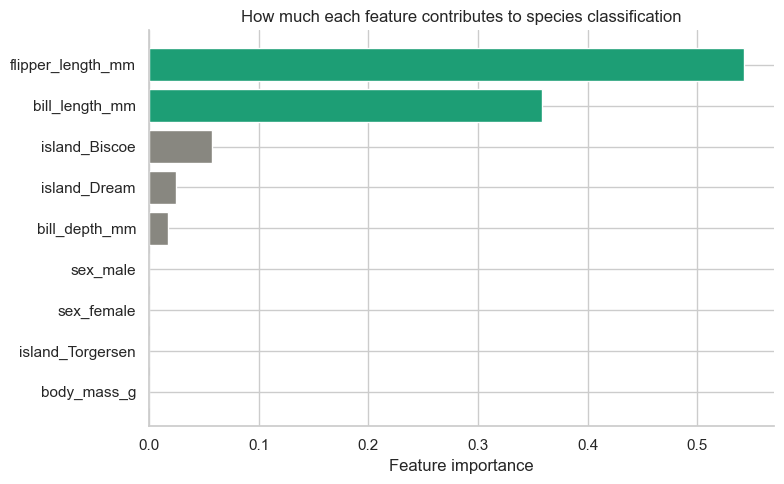

In [47]:
importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#1D9E75" if v > 0.1 else "#888780" for v in importances]
ax.barh(importances.index, importances.values, color=colors)
ax.set_xlabel("Feature importance")
ax.set_title("How much each feature contributes to species classification")
plt.tight_layout()
plt.show()

<div style="background-color: #fef3c7; border-left: 4px solid #f59e0b; padding: 12px 16px; border-radius: 4px; margin: 16px 0;"><strong>Question for you</strong><br>Look at the importance ranking and compare it to your visual intuition from §5.<br>(a) Did the model rely on the same features you predicted from the pairplot?<br>(b) The one-hot encoded <code>island</code> columns — are they near the top or the bottom? Why? (Hint: revisit the §3 crosstab. If a feature already <em>perfectly</em> identifies one species, the tree doesn't need to use it after the first split.)</div>

## 12. Recap and stretch exercises

You just walked through a complete supervised-learning project on a real, messy dataset:

| Step | What you did | scikit-learn tool |
|---|---|---|
| Load | Read CSV-like data into a DataFrame | `palmerpenguins.load_penguins` |
| Clean | Dropped 11 rows with missing values | `pd.DataFrame.dropna` |
| Encode | Converted categorical → numerical | `pd.get_dummies` |
| Split | Held out 25% with stratification | `train_test_split` |
| Train | Fit a Decision Tree | `DecisionTreeClassifier.fit` |
| Evaluate | Confusion matrix and classification report | `confusion_matrix`, `classification_report` |
| Validate | 5-fold cross-validation | `KFold`, `cross_val_score` |
| Tune | Grid search over hyperparameters | `GridSearchCV` |
| Interpret | Feature importances | `tree.feature_importances_` |

### Stretch exercises

Pick whichever of these grabs you. The first three are short, the last two are bigger.


<div style="background-color: #dcfce7; border-left: 4px solid #16a34a; padding: 12px 16px; border-radius: 4px; margin: 16px 0;"><strong>Try it yourself</strong><br><strong>1. Try a different model.</strong> Replace the Decision Tree with a <code>RandomForestClassifier</code> (no tuning needed — defaults are fine). Does it beat the tuned tree? By how much?</div>

In [84]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=10, random_state=RANDOM_STATE)
rf.fit(X_train, y_train)

rf_test_acc = accuracy_score(y_test, rf.predict(X_test))
tuned_tree_acc = accuracy_score(y_test, y_pred_best)

print(f"Tuned Decision Tree:    {tuned_tree_acc:.4f}")
print(f"Random Forest (default): {rf_test_acc:.4f}")
print(f"Improvement:             {rf_test_acc - tuned_tree_acc:+.4f}")
print()
print(classification_report(y_test, rf.predict(X_test), digits=3))

Tuned Decision Tree:    0.9643
Random Forest (default): 1.0000
Improvement:             +0.0357

              precision    recall  f1-score   support

      Adelie      1.000     1.000     1.000        37
   Chinstrap      1.000     1.000     1.000        17
      Gentoo      1.000     1.000     1.000        30

    accuracy                          1.000        84
   macro avg      1.000     1.000     1.000        84
weighted avg      1.000     1.000     1.000        84



<div style="background-color: #dcfce7; border-left: 4px solid #16a34a; padding: 12px 16px; border-radius: 4px; margin: 16px 0;"><strong>Try it yourself</strong><br><strong>2. Two-feature classifier.</strong> The pairplot in §5 suggested that <code>bill_length_mm</code> and <code>bill_depth_mm</code> alone might already be enough. Train a Decision Tree using <em>only</em> those two features and report its test accuracy. How much do you give up by ignoring the rest?</div>

In [86]:
X_two = penguins_encoded[["bill_length_mm", "bill_depth_mm"]]
y_two = penguins_encoded["species"]

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X_two, y_two,
    test_size=0.25,
    stratify=y_two,
    random_state=RANDOM_STATE,
)

tree2 = DecisionTreeClassifier(criterion="gini", max_depth=3, random_state=RANDOM_STATE)
tree2.fit(X2_train, y2_train)

acc_two = accuracy_score(y2_test, tree2.predict(X2_test))
print(f"Test accuracy with only 2 features:  {acc_two:.4f}")
print(f"Test accuracy with full feature set: {accuracy_score(y_test, y_pred_best):.4f}")
print(f"Difference (cost of the simpler model): {acc_two - accuracy_score(y_test, y_pred_best):+.4f}")

Test accuracy with only 2 features:  0.9048
Test accuracy with full feature set: 0.9643
Difference (cost of the simpler model): -0.0595


<div style="background-color: #dcfce7; border-left: 4px solid #16a34a; padding: 12px 16px; border-radius: 4px; margin: 16px 0;"><strong>Try it yourself</strong><br><strong>3. The hardest test.</strong> Hide the <code>island</code> feature entirely (drop the three <code>island_*</code> columns before training) and re-tune the model with grid search. How much does accuracy drop? This tells you how much the model was leaning on geography rather than biology — an important question if you ever wanted to deploy this classifier on penguins from a new island.</div>

In [70]:
island_cols = [c for c in X.columns if c.startswith("island_")]
X_no_island = X.drop(columns=island_cols)

print(f"Removed columns: {island_cols}")
print(f"Remaining features: {list(X_no_island.columns)}")
print()

Xn_train, Xn_test, yn_train, yn_test = train_test_split(
    X_no_island, y,
    test_size=0.25, stratify=y, random_state=RANDOM_STATE,
)

grid_no_island = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_grid=param_grid,
    cv=KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring="accuracy", n_jobs=-1,
)
grid_no_island.fit(Xn_train, yn_train)

acc_with_island    = accuracy_score(y_test,  y_pred_best)
acc_without_island = accuracy_score(yn_test, grid_no_island.predict(Xn_test))

print(f"Test acc (with    island): {acc_with_island:.4f}")
print(f"Test acc (without island): {acc_without_island:.4f}")
print(f"Drop:                      {acc_with_island - acc_without_island:+.4f}")

Removed columns: ['island_Biscoe', 'island_Dream', 'island_Torgersen']
Remaining features: ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex_female', 'sex_male']

Test acc (with    island): 0.9643
Test acc (without island): 0.9524
Drop:                      +0.0119


---

### Where to go next

When you are comfortable with this notebook, you have all the prerequisites for the next chapters: ensemble methods (bagging, boosting), unsupervised learning (clustering), and dimensionality reduction. Every workflow you'll meet from here on has the same skeleton you just practiced — load, clean, encode, split, fit, evaluate, tune, interpret.
